# README

### © Matteo Di Giovanni, Davide Rozza 2024, 2026

This code reads the modified ET sensitivity curves from .mat files and saves them into .txt filed to be read by the python code which makes the analysis.

This program is free software; you can redistribute it and/or
modify it under the terms of the GNU General Public License
as published by the Free Software Foundation; either version 2
of the License, or (at your option) any later version.

This program is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
GNU General Public License for more details.

You should have received a copy of the GNU General Public License
along with this program; if not, write to the Free Software
Foundation, Inc., 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301,
USA.


In [1]:
import scipy.io
import matplotlib.pyplot as plt
import numpy as np
import os
import csv

## Example on reading .mat files

In [ ]:
# load ET computed with new NN
ET_Noise_file  = scipy.io.loadmat('../sens_curves/ETNoise_P2TERZ_1year.mat')
print(ET_Noise_file)

In [3]:
ET_Noise_f     = ET_Noise_file['ET_Noise_f'][0]
ASD_ETall      = ET_Noise_file['ASD_ETall'][0]
ASD_ET_P2_10   = ET_Noise_file['ASD_ET_P2_10'][0]
ASD_ET_P2_50   = ET_Noise_file['ASD_ET_P2_50'][0]
ASD_ET_P2_90   = ET_Noise_file['ASD_ET_P2_90'][0]
ASD_ET_TERZ_10 = ET_Noise_file['ASD_ET_TERZ_10'][0]
ASD_ET_TERZ_50 = ET_Noise_file['ASD_ET_TERZ_50'][0]
ASD_ET_TERZ_90 = ET_Noise_file['ASD_ET_TERZ_90'][0]

{'__header__': b'MATLAB 5.0 MAT-file Platform: posix, Created on: Thu May  2 11:04:36 2024', '__version__': '1.0', '__globals__': [], 'ET_Noise_f': array([[   1.        ,    1.00230601,    1.00461733, ...,  995.40388884,
         997.6992978 , 1000.        ]], shape=(1, 3000)), 'ASD_ETall': array([[4.45656207e-17, 4.63344804e-17, 4.82245294e-17, ...,
        5.21416022e-25, 5.22284136e-25,            nan]], shape=(1, 3000)), 'ASD_ET_P2_10': array([[4.45656120e-17, 4.63344723e-17, 4.82245219e-17, ...,
        5.21416378e-25, 5.22284492e-25,            nan]], shape=(1, 3000)), 'ASD_ET_P2_50': array([[4.45656134e-17, 4.63344736e-17, 4.82245231e-17, ...,
        5.21418551e-25, 5.22286661e-25,            nan]], shape=(1, 3000)), 'ASD_ET_P2_90': array([[4.45656227e-17, 4.63344822e-17, 4.82245311e-17, ...,
        5.21424861e-25, 5.22292961e-25,            nan]], shape=(1, 3000)), 'ASD_ET_TERZ_10': array([[4.45656119e-17, 4.63344722e-17, 4.82245218e-17, ...,
        5.21427234e-25, 5.2229532

## Plot curves 

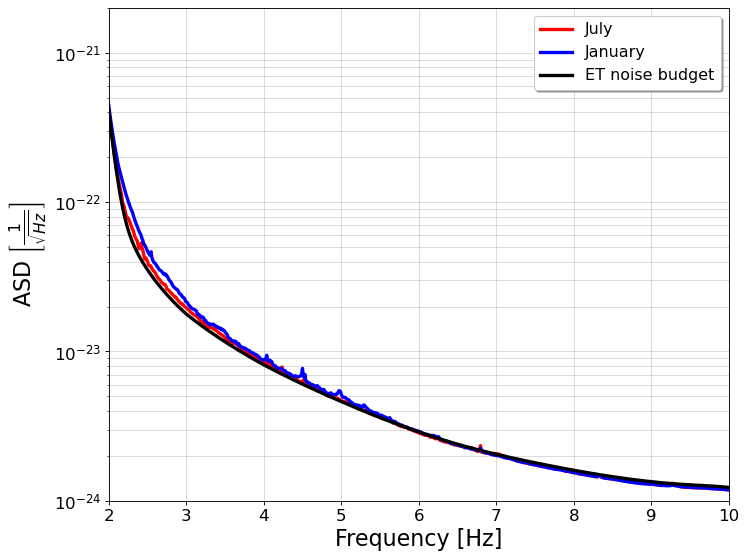

In [17]:
# Plot

fig, ax0=plt.subplots(figsize=(10, 8), dpi=80)
ax0.plot(ET_Noise_f, ASD_ET_P2_50, label="July", linewidth=3, color = 'r')
ax0.tick_params(which='both',labelsize=15)
ax0.set_yscale("log")
ax0.set_xlabel('Frequency [Hz]', size = 20)
ax0.set_ylabel(r'ASD $\left [\frac{1}{\sqrt{Hz}} \right ]$', size = 20)
plt.grid(which="both", c='gray', lw=0.5, alpha=0.5)
plt.ylim([1e-24, 2e-21])
plt.xlim([2,10])
legend = ax0.legend(loc='upper right', shadow=True, fontsize='x-large')
plt.show()




## Saves to .txt files

In [4]:
file = open('./sens_curves/ET_P2_90th_perc_1year.txt','w')
[file.write("%e %e\n" %(ET_Noise_f[k], ASD_ET_P2_90[k])) for k in range(len(ET_Noise_f))]
file.close()

file = open('./sens_curves/ET_P2_10th_perc_1year.txt','w')
[file.write("%e %e\n" %(ET_Noise_f[k], (ASD_ET_P2_10[k]))) for k in range(len(ET_Noise_f))]
file.close()

file = open('./sens_curves/ET_P2_50th_perc_1year.txt','w')
[file.write("%e %e\n" %(ET_Noise_f[k], ASD_ET_P2_50[k])) for k in range(len(ET_Noise_f))]
file.close()

file = open('./sens_curves/ET_ALL_NB.txt','w')
[file.write("%e %e\n" %(ET_Noise_f[k], ASD_ETall[k])) for k in range(len(ET_Noise_f))]
file.close()

file = open('./sens_curves/ET_TERZ_10th_perc_1year.txt','w')
[file.write("%e %e\n" %(ET_Noise_f[k], ASD_ET_TERZ_10[k])) for k in range(len(ET_Noise_f))]
file.close()

file = open('./sens_curves/ET_TERZ_50th_perc_1year.txt','w')
[file.write("%e %e\n" %(ET_Noise_f[k], ASD_ET_TERZ_50[k])) for k in range(len(ET_Noise_f))]
file.close()

file = open('./sens_curves/ET_TERZ_90th_perc_1year.txt','w')
[file.write("%e %e\n" %(ET_Noise_f[k], ASD_ET_TERZ_90[k])) for k in range(len(ET_Noise_f))]
file.close()